In [5]:
# Pré-requisito: Instalação das bibliotecas no ambiente virtual
! pip install python-bcb ipeadatapy pandas-datareader scikit-learn --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 27.4 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [6]:
# 1. Importação das bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

# Extração de Dados
from bcb import sgs
import ipeadatapy as ipea
import pandas_datareader.data as web

# Machine Learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Configuração visual
sns.set_theme(style="whitegrid", palette="muted")

In [7]:
# 2. Coleta dos Fundamentos Macroeconômicos
print("1. Extraindo dados do Banco Central do Brasil (SGS)...")
# 3698: Câmbio (Média Mensal) | 4390: Selic Mensal | 27574: IC-Br (Commodities)
df_bcb = sgs.get({'Dolar': 3698, 'Selic': 4390, 'IC_Br': 27574}, start='2010-01-01')
df_bcb.index = df_bcb.index.to_period('M').to_timestamp() # Padroniza para o dia 1º do mês

print("2. Extraindo dados do Federal Reserve (EUA)...")
# FEDFUNDS: Taxa de Juros Americana
data_inicio = datetime.datetime(2010, 1, 1)
df_fed = web.DataReader('FEDFUNDS', 'fred', data_inicio)
df_fed.index = df_fed.index.to_period('M').to_timestamp()

print("3. Extraindo dados do IPEADATA (Risco Brasil - EMBI+)...")
# JPM366_EMBI366: Risco Soberano Brasil
df_ipea = ipea.timeseries('JPM366_EMBI366')

# Encontra dinamicamente a coluna que contém os valores
coluna_valor = [col for col in df_ipea.columns if 'VALUE' in col.upper() or 'VAL' in col.upper()][0]

df_ipea = df_ipea[[coluna_valor]].rename(columns={coluna_valor: 'Risco_EMBI'})
df_ipea.index = pd.to_datetime(df_ipea.index)
df_embi_mensal = df_ipea.resample('MS').mean() # Transforma diário em média mensal

print("4. Consolidando o DataFrame Final...")
# Junta todas as colunas usando a data como chave
df_macro = df_bcb.join(df_fed).join(df_embi_mensal)
df_macro = df_macro.rename(columns={'FEDFUNDS': 'Fed_Funds'})

# Trata valores vazios preenchendo com o mês anterior
df_macro = df_macro.ffill().dropna()
print("Base de dados estruturada com sucesso! Linhas:", len(df_macro))
display(df_macro.tail(3)) # Mostra os últimos 3 meses para auditoria

1. Extraindo dados do Banco Central do Brasil (SGS)...
2. Extraindo dados do Federal Reserve (EUA)...
3. Extraindo dados do IPEADATA (Risco Brasil - EMBI+)...
4. Consolidando o DataFrame Final...
Base de dados estruturada com sucesso! Linhas: 198


,Dolar,Selic,IC_Br,Fed_Funds,Risco_EMBI
Date,,,,,
2026-04-01,5.0331,1.09,443.33,3.64,226.904762
2026-05-01,4.9837,1.07,452.88,3.63,226.904762
2026-06-01,4.9837,0.70,452.88,3.63,226.904762


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

from bcb import sgs
import ipeadatapy as ipea
import pandas_datareader.data as web

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

sns.set_theme(style="whitegrid", palette="muted")

# 2. Coleta dos Fundamentos Macroeconômicos
print("1. Extraindo dados do Banco Central do Brasil (SGS)...")
df_bcb = sgs.get({'Dolar': 3698, 'Selic': 4390, 'IC_Br': 27574}, start='2010-01-01')
df_bcb.index = df_bcb.index.to_period('M').to_timestamp()

print("2. Extraindo dados do Federal Reserve (EUA)...")
data_inicio = datetime.datetime(2010, 1, 1)
df_fed = web.DataReader('FEDFUNDS', 'fred', data_inicio)
df_fed.index = df_fed.index.to_period('M').to_timestamp()

print("3. Extraindo dados do IPEADATA (Risco Brasil - EMBI+)...")
df_ipea = ipea.timeseries('JPM366_EMBI366')

coluna_valor = [col for col in df_ipea.columns if 'VALUE' in col.upper() or 'VAL' in col.upper()][0]
df_ipea = df_ipea[[coluna_valor]].rename(columns={coluna_valor: 'Risco_EMBI'})
df_ipea.index = pd.to_datetime(df_ipea.index)
df_embi_mensal = df_ipea.resample('MS').mean()

print("4. Consolidando o DataFrame Final...")
df_macro = df_bcb.join(df_fed).join(df_embi_mensal)
df_macro = df_macro.rename(columns={'FEDFUNDS': 'Fed_Funds'})
df_macro = df_macro.ffill().dropna()
print("Base de dados estruturada com sucesso! Linhas:", len(df_macro))

# 3. Engenharia de Variáveis e Treinamento do Modelo

# Criação das Variáveis Explicativas (Feature Engineering)
df_ml = df_macro.copy()
df_ml['Delta_Juros'] = df_ml['Selic'] - df_ml['Fed_Funds']
df_ml['Dolar_Lag1'] = df_ml['Dolar'].shift(1)

df_ml = df_ml.dropna()

# Definição das variáveis independentes (X) e dependente (y)
features = ['Delta_Juros', 'IC_Br', 'Risco_EMBI', 'Dolar_Lag1']
X = df_ml[features]
y = df_ml['Dolar']

# Separação Temporal: Treino (Até Dez/2023) vs Validação (Jan/2024 em diante)
corte_temporal = '2024-01-01'
X_treino = X[X.index < corte_temporal]
y_treino = y[y.index < corte_temporal]

X_teste = X[X.index >= corte_temporal]
y_teste = y[y.index >= corte_temporal]

# Instanciando e Treinando o Algoritmo (Random Forest Regressor)
modelo_rf = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
modelo_rf.fit(X_treino, y_treino)

# Realizando as Previsões no período de Validação
previsoes = modelo_rf.predict(X_teste)

# Calculando a margem de erro (RMSE extraindo a raiz quadrada manualmente)
rmse = mean_squared_error(y_teste, previsoes) ** 0.5
print(f"Modelo Treinado! Erro Quadrático Médio (RMSE) na previsão: R$ {rmse:.4f}")

# Calculando o erro percentual médio absoluto (MAPE) e multiplicando por 100 para transformar em percentual (%)
mape = mean_absolute_percentage_error(y_teste, previsoes) * 100
print(f"O MAPE do modelo é: {mape:.2f}%")

1. Extraindo dados do Banco Central do Brasil (SGS)...
2. Extraindo dados do Federal Reserve (EUA)...
3. Extraindo dados do IPEADATA (Risco Brasil - EMBI+)...
4. Consolidando o DataFrame Final...
Base de dados estruturada com sucesso! Linhas: 198
Modelo Treinado! Erro Quadrático Médio (RMSE) na previsão: R$ 0.3387
O MAPE do modelo é: 4.61%


### **Gráfico da Projeção Cambial (Real vs. Previsto)**



<>:10: SyntaxWarning: invalid escape sequence '\$'
<>:10: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_8185/1576912320.py:10: SyntaxWarning: invalid escape sequence '\$'
  ax1.set_ylabel('Taxa de Câmbio (R\$/US\$)', fontsize=12)


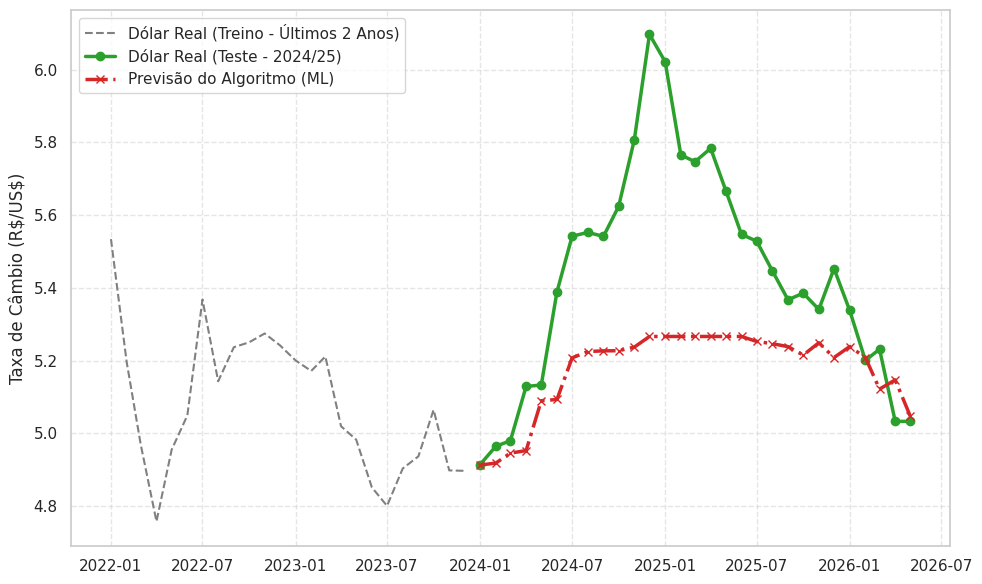

In [ ]:
# 4. Visualização 1 – Projeção Cambial Real vs. Machine Learning
fig_previsao, ax1 = plt.subplots(figsize=(10, 6))

# Cores e estilos acadêmicos
cor_real = '#2ca02c'  # Verde Real
cor_prev = '#d62728'  # Vermelho tracejado

# Configuração da área gráfica
ax1.set_ylabel('Taxa de Câmbio (R$/US$)', fontsize=12)

# Plotagem das séries
ax1.plot(y_treino.index[-24:], y_treino.tail(24), label='Dólar Real (Treino - Últimos 2 Anos)', color='gray', linestyle='--')
ax1.plot(y_teste.index, y_teste, label='Dólar Real (Teste - 2024/25)', color=cor_real, linewidth=2.5, marker='o')
ax1.plot(y_teste.index, previsoes, label='Previsão do Algoritmo (ML)', color=cor_prev, linewidth=2.5, marker='x', linestyle='-.')

# Configurações de eixo e legenda
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### **Gráfico da Importância das Variáveis (Feature Importance)**

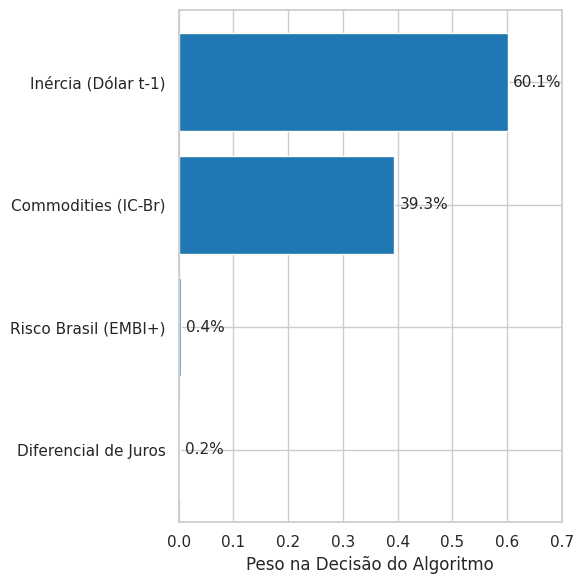

In [ ]:
# 5. Visualização 2 – Importância das Variáveis (Feature Importance)

# Extrai e formata a importância
importancias = modelo_rf.feature_importances_
df_imp = pd.DataFrame({'Variável': features, 'Importância': importancias}).sort_values('Importância', ascending=True)

# Renomeando nomenclatura para o gráfico
nomes_elegantes = {'Dolar_Lag1': 'Inércia (Dólar t-1)', 'Risco_EMBI': 'Risco Brasil (EMBI+)',
                   'IC_Br': 'Commodities (IC-Br)', 'Delta_Juros': 'Diferencial de Juros'}
df_imp['Variável'] = df_imp['Variável'].map(nomes_elegantes)

fig_imp, ax2 = plt.subplots(figsize=(6, 6))

# Configuração gráfica
bars = ax2.barh(df_imp['Variável'], df_imp['Importância'], color='#1f77b4')
ax2.set_xlabel('Peso na Decisão do Algoritmo', fontsize=12)

# Expandindo o limite do eixo X para otimizar a margem de leitura dos percentuais
ax2.set_xlim(0, 0.7)

# Adicionando o percentual nas barras
for bar in bars:
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width()*100:.1f}%', va='center', fontsize=11)

plt.tight_layout()
plt.show()